# Maratończycy: mini projekt badawczy / pilot study

## Pomysł

Traktujemy dotychczasową analizę jako **pilot study**: próbujemy zidentyfikować ciekawe wzorce i hipotezy, które później można sprawdzać na większych lub niezależnych danych.

## Pytania badawcze

1. Czy czasy maratońskie są lepiej opisywane przez rozkłady dodatnie i prawoskośne niż przez rozkład normalny?
2. Czy wraz z wiekiem zmienia się tylko poziom wyników, czy także **kształt rozkładu**?
3. Czy różnice między płciami dotyczą głównie przesunięcia rozkładu, czy również jego kształtu?
4. Czy pozorna większa symetria na krańcach wieku może wynikać z małej próby i selekcji populacji?
5. Jak wiek i płeć wpływają na strategię biegu: spowolnienie i `negative split`?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

candidate_paths = [
    Path('marathon-data.csv'),
    Path('/mnt/data/marathon-data.csv'),
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Nie znaleziono pliku marathon-data.csv')

df = pd.read_csv(DATA_PATH)

for col in ['split', 'final']:
    df[col + '_td'] = pd.to_timedelta(df[col])
    df[col + '_min'] = df[col + '_td'].dt.total_seconds() / 60

df['slowdown_min'] = df['final_min'] - 2 * df['split_min']
df['slowdown_pct'] = 100 * df['slowdown_min'] / df['final_min']
df['negative_split'] = df['slowdown_min'] < 0

age_bins = [15, 19, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 100]
age_labels = ['16-19', '20-24', '25-29', '30-34', '35-39', '40-44',
              '45-49', '50-54', '55-59', '60-64', '65-69', '70+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

df.head()

/home/oai/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-l4jf1qh8 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,age,gender,split,final,split_td,split_min,final_td,final_min,slowdown_min,slowdown_pct,negative_split,age_group
0,33,M,01:05:38,02:08:51,0 days 01:05:38,65.633333,0 days 02:08:51,128.850000,-2.416667,-1.875566,True,30-34
1,32,M,01:06:26,02:09:28,0 days 01:06:26,66.433333,0 days 02:09:28,129.466667,-3.400000,-2.626159,True,30-34
2,31,M,01:06:49,02:10:42,0 days 01:06:49,66.816667,0 days 02:10:42,130.700000,-2.933333,-2.244325,True,30-34
3,38,M,01:06:16,02:13:45,0 days 01:06:16,66.266667,0 days 02:13:45,133.750000,1.216667,0.909657,False,35-39
4,31,M,01:06:32,02:13:59,0 days 01:06:32,66.533333,0 days 02:13:59,133.983333,0.916667,0.684165,False,30-34


## 1. Rozkład globalny: który model jest sensowny?

Zaczynamy od pytania, czy czasy końcowe bardziej przypominają:
- rozkład normalny,
- lognormalny,
- gamma,
- czy Weibulla.

Do porównania użyjemy prostego kryterium jakości dopasowania: **AIC**.  
Niższy AIC oznacza lepsze dopasowanie przy podobnej liczbie parametrów.

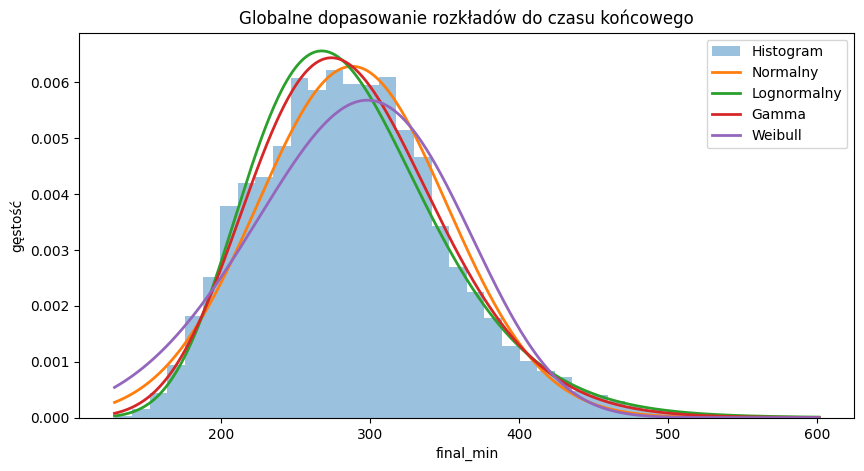

,model,AIC
2,gamma,413530.9
1,lognormal,413642.4
0,normal,415008.3
3,weibull,417470.5


In [2]:
def aic_from_loglik(k, ll):
    return 2 * k - 2 * ll

x = df['final_min'].dropna().to_numpy()

# Dopasowania globalne
mu, sigma = stats.norm.fit(x)
sh_ln, loc_ln, sc_ln = stats.lognorm.fit(x, floc=0)
a_g, loc_g, sc_g = stats.gamma.fit(x, floc=0)
c_w, loc_w, sc_w = stats.weibull_min.fit(x, floc=0)

ll_norm = np.sum(stats.norm.logpdf(x, loc=mu, scale=sigma))
ll_logn = np.sum(stats.lognorm.logpdf(x, s=sh_ln, loc=loc_ln, scale=sc_ln))
ll_gamma = np.sum(stats.gamma.logpdf(x, a=a_g, loc=loc_g, scale=sc_g))
ll_weib = np.sum(stats.weibull_min.logpdf(x, c=c_w, loc=loc_w, scale=sc_w))

fit_global = pd.DataFrame({
    'model': ['normal', 'lognormal', 'gamma', 'weibull'],
    'AIC': [
        aic_from_loglik(2, ll_norm),
        aic_from_loglik(2, ll_logn),
        aic_from_loglik(2, ll_gamma),
        aic_from_loglik(2, ll_weib),
    ]
}).sort_values('AIC')

xx = np.linspace(x.min(), x.max(), 500)
plt.figure(figsize=(10, 5))
plt.hist(x, bins=40, density=True, alpha=0.45, label='Histogram')
plt.plot(xx, stats.norm.pdf(xx, loc=mu, scale=sigma), label='Normalny', linewidth=2)
plt.plot(xx, stats.lognorm.pdf(xx, s=sh_ln, loc=loc_ln, scale=sc_ln), label='Lognormalny', linewidth=2)
plt.plot(xx, stats.gamma.pdf(xx, a=a_g, loc=loc_g, scale=sc_g), label='Gamma', linewidth=2)
plt.plot(xx, stats.weibull_min.pdf(xx, c=c_w, loc=loc_w, scale=sc_w), label='Weibull', linewidth=2)
plt.title('Globalne dopasowanie rozkładów do czasu końcowego')
plt.xlabel('final_min')
plt.ylabel('gęstość')
plt.legend()
plt.show()

fit_global.round(1)

### Wstępny wniosek

Już globalnie widać, że rozkład normalny nie jest najlepszym opisem danych.  
Dla dodatnich, prawoskośnych czasów lepsze są zwykle rozkłady **lognormalny** albo **gamma**.

## 2. Kształt rozkładu po wieku i płci

Teraz sprawdzamy, czy:
- kształt rozkładu jest podobny między grupami,
- skośność maleje lub rośnie z wiekiem,
- oraz czy różnice między płciami dotyczą bardziej położenia czy także kształtu rozkładu.

Wykorzystamy:
- liczebność `n`,
- średnią i medianę,
- różnicę `mean - median`,
- skośność (`skewness`),
- kurtozę.

In [3]:
shape_summary = (
    df.groupby(['age_group', 'gender'], observed=False)['final_min']
      .agg(
          n='size',
          mean='mean',
          median='median',
          std='std',
          skewness=lambda x: stats.skew(x, bias=False),
          kurtosis=lambda x: stats.kurtosis(x, bias=False),
      )
      .reset_index()
)

shape_summary['mean_minus_median'] = shape_summary['mean'] - shape_summary['median']
shape_summary.round(3)

,age_group,gender,n,mean,median,std,skewness,kurtosis,mean_minus_median
0,16-19,M,87,292.797,285.267,65.683,1.529,4.079,7.530
1,16-19,W,44,316.528,317.283,56.064,-0.329,0.316,-0.755
2,20-24,M,656,274.634,275.492,65.289,0.378,0.375,-0.858
3,20-24,W,540,302.794,302.342,61.592,0.216,-0.000,0.452
4,25-29,M,2129,268.160,264.600,60.759,0.437,0.173,3.560
5,25-29,W,2117,301.654,301.333,58.055,0.388,0.341,0.321
6,30-34,M,3370,265.995,261.125,58.958,0.482,0.247,4.870
7,30-34,W,2238,303.600,302.683,58.964,0.271,0.161,0.917
8,35-39,M,4227,269.227,264.617,58.490,0.545,0.423,4.610
9,35-39,W,2159,307.293,305.750,61.629,0.311,0.105,1.543


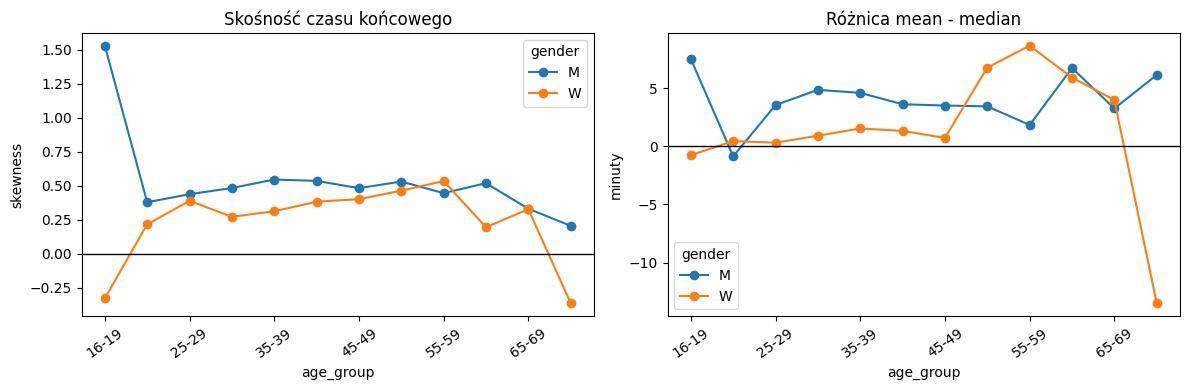

In [4]:
skew_pivot = shape_summary.pivot(index='age_group', columns='gender', values='skewness')
gap_pivot = shape_summary.pivot(index='age_group', columns='gender', values='mean_minus_median')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
skew_pivot.plot(marker='o', ax=axes[0], title='Skośność czasu końcowego')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_ylabel('skewness')
axes[0].tick_params(axis='x', rotation=35)

gap_pivot.plot(marker='o', ax=axes[1], title='Różnica mean - median')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_ylabel('minuty')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

### Interpretacja

Jeśli rozkład staje się bardziej symetryczny, to zwykle:
- skośność zbliża się do zera,
- średnia i mediana są bliżej siebie.

To jest prostsze i bardziej formalne niż samo ocenianie histogramu „na oko”.

## 3. Czy na krańcach wieku „gaussowatość” może być artefaktem małej próby?

To jest kluczowe pytanie.

Hipoteza robocza:
- w skrajnych grupach wieku rozkłady mogą wyglądać bardziej regularnie lub bardziej symetrycznie,
- ale część tego efektu może wynikać z **małej liczebności**,
- a część z **selekcji populacji**.

Sprawdzimy to przez prosty eksperyment bootstrapowy:
- bierzemy dużą grupę referencyjną w średnim wieku,
- losujemy z niej wiele małych prób o tej samej liczności co grupa skrajna,
- porównujemy skośność tych prób ze skośnością obserwowaną.

In [5]:
def bootstrap_sample_skew(reference, n, reps=4000, seed=42):
    rng = np.random.default_rng(seed)
    reference = np.asarray(reference)
    return np.array([
        stats.skew(rng.choice(reference, size=n, replace=True), bias=False)
        for _ in range(reps)
    ])

comparisons = []
for gender in ['M', 'W']:
    ref = df[(df['age_group'] == '40-44') & (df['gender'] == gender)]['final_min'].dropna().to_numpy()
    for age_group in ['16-19', '70+']:
        obs = df[(df['age_group'] == age_group) & (df['gender'] == gender)]['final_min'].dropna().to_numpy()
        if len(obs) >= 20:
            boots = bootstrap_sample_skew(ref, len(obs), reps=4000, seed=42 + len(obs))
            comparisons.append({
                'gender': gender,
                'age_group': age_group,
                'n': len(obs),
                'observed_skew': stats.skew(obs, bias=False),
                'boot_q025': np.quantile(boots, 0.025),
                'boot_q50': np.quantile(boots, 0.50),
                'boot_q975': np.quantile(boots, 0.975),
                'percentile_vs_boot': (boots <= stats.skew(obs, bias=False)).mean(),
                'boot_values': boots,
            })

bootstrap_summary = pd.DataFrame([{k:v for k,v in d.items() if k!='boot_values'} for d in comparisons])
bootstrap_summary.round(3)

,gender,age_group,n,observed_skew,boot_q025,boot_q50,boot_q975,percentile_vs_boot
0,M,16-19,87,1.529,-0.029,0.500,1.104,0.999
1,M,70+,142,0.205,0.087,0.513,0.994,0.080
2,W,16-19,44,-0.329,-0.270,0.328,1.048,0.017
3,W,70+,24,-0.364,-0.561,0.280,1.224,0.064


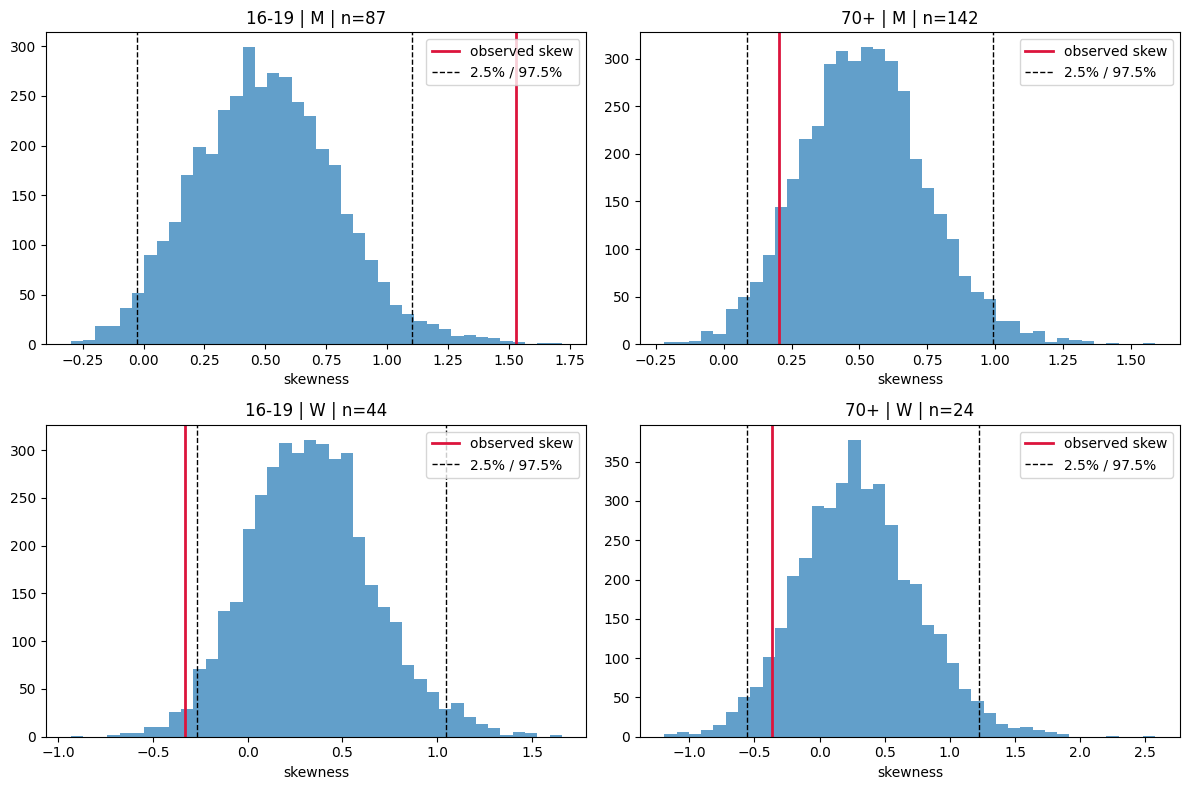

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, comp in zip(axes, comparisons):
    ax.hist(comp['boot_values'], bins=40, alpha=0.7)
    ax.axvline(comp['observed_skew'], color='crimson', linewidth=2, label='observed skew')
    ax.axvline(comp['boot_q025'], color='black', linestyle='--', linewidth=1, label='2.5% / 97.5%')
    ax.axvline(comp['boot_q975'], color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{comp['age_group']} | {comp['gender']} | n={comp['n']}")
    ax.set_xlabel('skewness')
    ax.legend()

plt.tight_layout()
plt.show()

### Jak czytać bootstrap?

Jeśli obserwowana skośność ekstremalnej grupy mieści się w szerokim zakresie bootstrapowym z próbek o tym samym `n`, to część „dziwności” histogramu może wynikać po prostu z małej próby.

Jeśli natomiast obserwowana skośność wyraźnie odstaje od rozkładu bootstrapowego, to rośnie szansa, że działa tu coś więcej niż tylko sampling noise.

## 4. Strategia biegu: spowolnienie i `negative split`

Teraz przechodzimy od samego wyniku do strategii biegu.

Pytania:
1. Czy spowolnienie rośnie wraz z wiekiem?
2. Czy kobiety i mężczyźni różnią się pod tym względem?
3. Jak często pojawia się `negative split`?

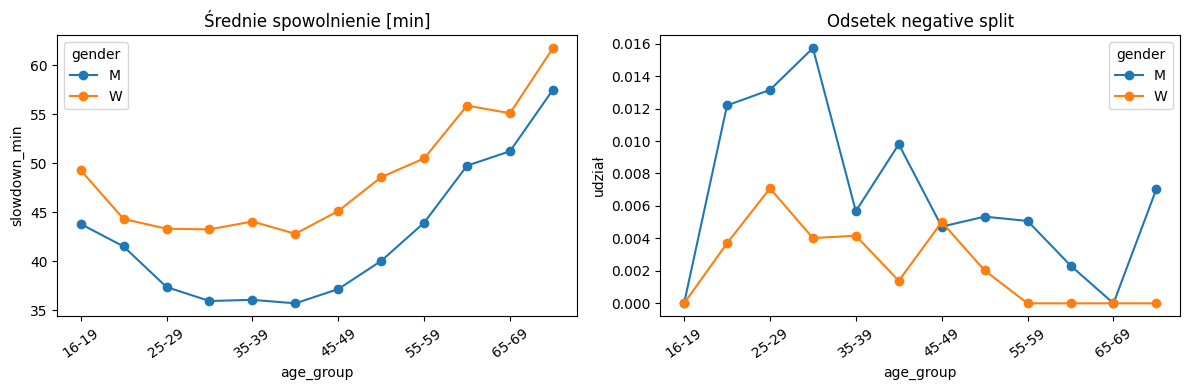

Spowolnienie:


gender,M,W
age_group,,
16-19,43.80,49.29
20-24,41.50,44.30
25-29,37.36,43.31
30-34,35.93,43.24
35-39,36.05,44.05
40-44,35.70,42.79
45-49,37.15,45.12
50-54,40.03,48.58
55-59,43.93,50.49


Negative split:


gender,M,W
age_group,,
16-19,0.000,0.000
20-24,0.012,0.004
25-29,0.013,0.007
30-34,0.016,0.004
35-39,0.006,0.004
40-44,0.010,0.001
45-49,0.005,0.005
50-54,0.005,0.002
55-59,0.005,0.000


In [7]:
pivot_slow = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='slowdown_min',
    aggfunc='mean',
    observed=False
)

pivot_neg = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='negative_split',
    aggfunc='mean',
    observed=False
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pivot_slow.plot(marker='o', ax=axes[0], title='Średnie spowolnienie [min]')
axes[0].set_ylabel('slowdown_min')
axes[0].tick_params(axis='x', rotation=35)

pivot_neg.plot(marker='o', ax=axes[1], title='Odsetek negative split')
axes[1].set_ylabel('udział')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

print("Spowolnienie:")
display(pivot_slow.round(2))
print("Negative split:")
display(pivot_neg.round(3))

### Wstępny wniosek

Tu można sprawdzić, czy różnice między grupami dotyczą tylko poziomu wyniku, czy też sposobu rozłożenia sił.

Jeśli spowolnienie rośnie z wiekiem i jest różne między płciami, to znaczy, że wiek i płeć wpływają nie tylko na czas końcowy, ale też na **dynamikę biegu**.

## 5. Czy pierwsza połowa wiąże się ze spowolnieniem później?

To pytanie jest ciekawe, bo dotyczy strategii:
- czy szybszy / wolniejszy półmaraton wiąże się z późniejszym większym spadkiem tempa?

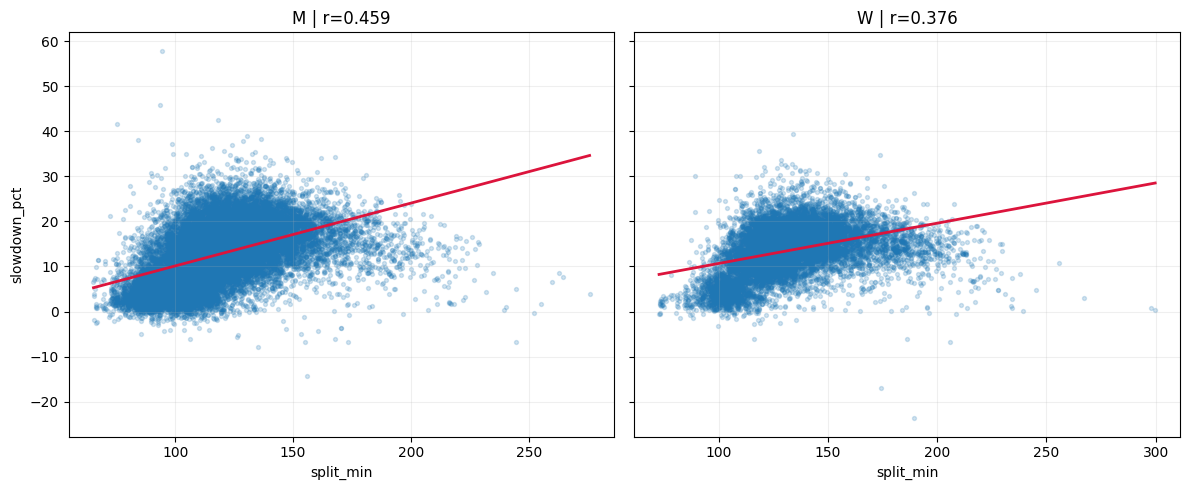

,gender,slope,r,p
0,M,0.1396,0.4588,0.0
1,W,0.0894,0.3758,0.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

reg_rows = []
for ax, gender in zip(axes, ['M', 'W']):
    sub = df[df['gender'] == gender]
    slope, intercept, r, p, se = stats.linregress(sub['split_min'], sub['slowdown_pct'])
    x_line = np.linspace(sub['split_min'].min(), sub['split_min'].max(), 200)
    y_line = slope * x_line + intercept

    ax.scatter(sub['split_min'], sub['slowdown_pct'], s=8, alpha=0.2)
    ax.plot(x_line, y_line, color='crimson', linewidth=2)
    ax.set_title(f'{gender} | r={r:.3f}')
    ax.set_xlabel('split_min')
    ax.grid(alpha=0.2)

    reg_rows.append({'gender': gender, 'slope': slope, 'r': r, 'p': p})

axes[0].set_ylabel('slowdown_pct')
plt.tight_layout()
plt.show()

pd.DataFrame(reg_rows).round(4)

### Jak czytać ten wykres?

Jeśli zależność jest dodatnia, to wolniejsza pierwsza połowa wiąże się przeciętnie z większym spowolnieniem procentowym.

To nie musi oznaczać „strategii” w sensie przyczynowym.  
Może też odzwierciedlać ogólny poziom wydolności: słabsi biegacze są wolniejsi i jednocześnie mniej stabilni.

## 6. Podsumowanie pilot study

### Co już widać dość wyraźnie?

1. Rozkład czasu końcowego jest prawoskośny i lepiej opisują go rozkłady dodatnie, zwłaszcza **lognormalny** lub **gamma**.
2. Wiek zmienia nie tylko średni poziom wyniku, ale także szerokość i czasem skośność rozkładu.
3. Płeć wpływa głównie na **poziom** wyników, podczas gdy kształt rozkładu pozostaje podobny.
4. Spowolnienie rośnie wraz z wiekiem i różni się między płciami.
5. `Negative split` jest rzadki, co sugeruje, że większość biegaczy zwalnia po połowie.

### Co jest hipotezą, a nie twardym wnioskiem?

Na krańcach wieku rozkłady mogą wyglądać bardziej regularnie lub bardziej symetrycznie.  
To może wynikać z:
- małej liczebności prób,
- selekcji populacji,
- albo z realnej większej jednorodności tej grupy.

Na podstawie tego jednego zbioru nie rozstrzygamy mechanizmu przyczynowego — traktujemy to jako **hipotezę do dalszego testowania**.

## 7. Ograniczenia i następne kroki

### Ograniczenia
- To tylko jeden zbiór danych.
- Nie mamy zmiennych treningowych, zdrowotnych ani longitudinalnych.
- W małych grupach histogramy i estymacje są niestabilne.

### Następne kroki
1. Powtórzyć analizę na innych maratonach.
2. Formalnie porównać modele rozkładu (AIC, KS, bootstrap).
3. Zbadać selekcję na krańcach wieku na większych danych.
4. Rozszerzyć analizę o prosty model regresyjny dla `final_min`, `slowdown_min` i `negative_split`.